In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../dataset/fer2013/fer2013.csv")

df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   pixels   35887 non-null  object
 2   Usage    35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB


In [4]:
print("Shape:", df.shape)

Shape: (35887, 3)


In [5]:
df.isnull().sum()

emotion    0
pixels     0
Usage      0
dtype: int64

# Exploratory Data Analysis (EDA)

The FER2013 dataset consists of facial images represented as pixel values.
Each image is 48×48 pixels in grayscale and belongs to one of seven emotion classes.
The dataset also contains predefined Training, PublicTest and PrivateTest splits.

In [6]:
emotion_labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

In [7]:
emotion_counts = df["emotion"].value_counts().sort_index()

emotion_counts

emotion
0    4953
1     547
2    5121
3    8989
4    6077
5    4002
6    6198
Name: count, dtype: int64

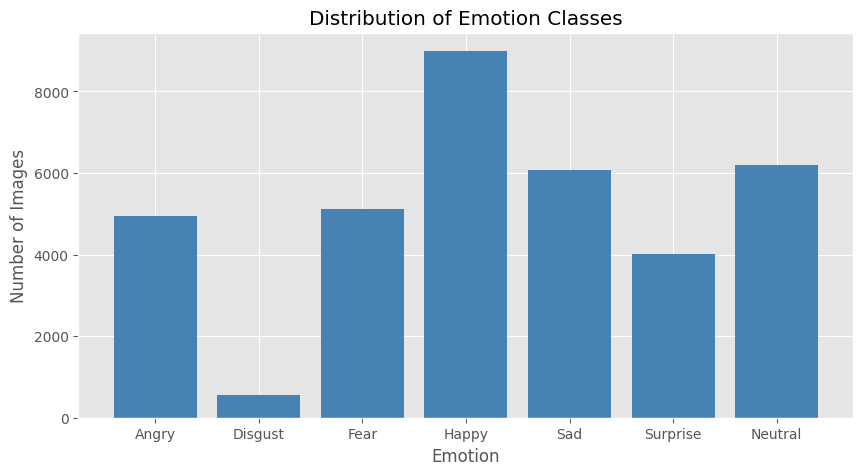

In [8]:
plt.figure(figsize=(10,5))

plt.bar(
    [emotion_labels[i] for i in emotion_counts.index],
    emotion_counts.values,
    color="steelblue"
)

plt.title("Distribution of Emotion Classes")

plt.xlabel("Emotion")

plt.ylabel("Number of Images")

plt.show()

In [9]:
df["Usage"].value_counts()

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

In [10]:
from tensorflow.keras.utils import to_categorical

In [11]:
df = pd.read_csv("../dataset/fer2013/fer2013.csv")

df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [12]:
pixels = df["pixels"].tolist()

faces = []

for pixel_sequence in pixels:
    face = np.array(pixel_sequence.split(), dtype=np.float32)
    faces.append(face)

faces = np.array(faces)

print(faces.shape)

(35887, 2304)


In [13]:
faces = faces.reshape(-1, 48, 48, 1)

print(faces.shape)

(35887, 48, 48, 1)


In [14]:
faces = faces / 255.0

print(faces.min())
print(faces.max())

0.0
1.0


In [15]:
labels = df["emotion"].values

print(labels[:10])

[0 0 2 4 6 2 4 3 3 2]


In [16]:
Happy = 3
Sad = 4

In [17]:
labels = to_categorical(labels, num_classes=7)

print(labels.shape)

(35887, 7)


In [18]:
train_mask = df["Usage"] == "Training"

X_train = faces[train_mask]
y_train = labels[train_mask]

In [19]:
val_mask = df["Usage"] == "PublicTest"

X_val = faces[val_mask]
y_val = labels[val_mask]

In [20]:
test_mask = df["Usage"] == "PrivateTest"

X_test = faces[test_mask]
y_test = labels[test_mask]

In [21]:
print("Training:", X_train.shape, y_train.shape)

print("Validation:", X_val.shape, y_val.shape)

print("Testing:", X_test.shape, y_test.shape)

Training: (28709, 48, 48, 1) (28709, 7)
Validation: (3589, 48, 48, 1) (3589, 7)
Testing: (3589, 48, 48, 1) (3589, 7)


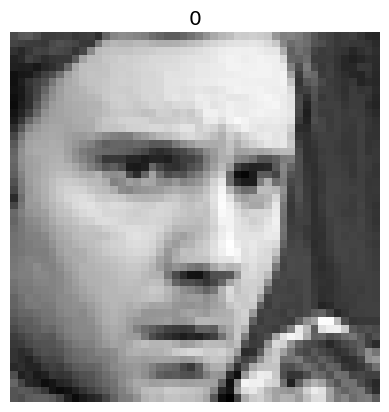

In [22]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0].squeeze(), cmap="gray")
plt.title(np.argmax(y_train[0]))
plt.axis("off")
plt.show()

In [23]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dense,
    Dropout,
    Flatten
)

In [24]:
model = Sequential()

# Block 1
model.add(Conv2D(
    32,
    (3,3),
    activation="relu",
    input_shape=(48,48,1)
))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(
    64,
    (3,3),
    activation="relu"
))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(
    128,
    (3,3),
    activation="relu"
))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(
    256,
    activation="relu"
))

model.add(Dropout(0.5))

model.add(Dense(
    7,
    activation="softmax"
))

c:\Users\ranji\MoodSync-AI-v2\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,911 (2.36 MB)

 Trainable params: 619,463 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [26]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

In [30]:
history = model.fit(

    X_train,

    y_train,

    validation_data=(X_val, y_val),

    epochs=25,

    batch_size=64,

    callbacks=[early_stop]

)

Epoch 1/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.6314 - loss: 0.9628 - val_accuracy: 0.5216 - val_loss: 1.2780
Epoch 2/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 36s 80ms/step - accuracy: 0.6566 - loss: 0.9051 - val_accuracy: 0.5536 - val_loss: 1.2140
Epoch 3/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 43s 95ms/step - accuracy: 0.6833 - loss: 0.8317 - val_accuracy: 0.5411 - val_loss: 1.2983
Epoch 4/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 53s 118ms/step - accuracy: 0.7025 - loss: 0.7796 - val_accuracy: 0.5472 - val_loss: 1.2735
Epoch 5/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 58s 128ms/step - accuracy: 0.7319 - loss: 0.7064 - val_accuracy: 0.5514 - val_loss: 1.3244


In [31]:
history = model.fit(

    X_train,

    y_train,

    validation_data=(X_val, y_val),

    epochs=25,

    batch_size=64,

    callbacks=[early_stop]

)

Epoch 1/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 39s 86ms/step - accuracy: 0.6613 - loss: 0.8902 - val_accuracy: 0.5294 - val_loss: 1.3320
Epoch 2/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 62s 138ms/step - accuracy: 0.6865 - loss: 0.8266 - val_accuracy: 0.5469 - val_loss: 1.2759
Epoch 3/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 83s 141ms/step - accuracy: 0.7051 - loss: 0.7693 - val_accuracy: 0.5553 - val_loss: 1.3042
Epoch 4/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 48s 106ms/step - accuracy: 0.7307 - loss: 0.7114 - val_accuracy: 0.5665 - val_loss: 1.3167
Epoch 5/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 39s 86ms/step - accuracy: 0.7497 - loss: 0.6549 - val_accuracy: 0.5701 - val_loss: 1.3933


In [32]:
print(early_stop)

In [33]:
print(early_stop.monitor)
print(early_stop.patience)
print(early_stop.restore_best_weights)

val_loss
5
True


In [34]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 55s 123ms/step - accuracy: 0.6899 - loss: 0.8202 - val_accuracy: 0.4859 - val_loss: 1.4876
Epoch 2/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 63s 139ms/step - accuracy: 0.7082 - loss: 0.7593 - val_accuracy: 0.5352 - val_loss: 1.4097
Epoch 3/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 69s 154ms/step - accuracy: 0.7303 - loss: 0.7104 - val_accuracy: 0.5634 - val_loss: 1.3136
Epoch 4/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 60s 134ms/step - accuracy: 0.7516 - loss: 0.6569 - val_accuracy: 0.5378 - val_loss: 1.4176
Epoch 5/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 60s 134ms/step - accuracy: 0.7669 - loss: 0.6055 - val_accuracy: 0.5698 - val_loss: 1.4311
Epoch 6/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 60s 133ms/step - accuracy: 0.7846 - loss: 0.5627 - val_accuracy: 0.5712 - val_loss: 1.5394
Epoch 7/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 60s 133ms/step - accuracy: 0.7964 - loss: 0.5326 - val_accuracy: 0.5751 - val_loss: 1.6020
Epoch 8/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 61s 135ms/step - accuracy: 0.8143 - loss: 0

In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=np.argmax(y_train, axis=1)
)

class_weights = dict(enumerate(class_weights))

In [36]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - accuracy: 0.6491 - loss: 0.9815 - val_accuracy: 0.5210 - val_loss: 1.4323
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 43s 90ms/step - accuracy: 0.6691 - loss: 0.8762 - val_accuracy: 0.5556 - val_loss: 1.3166
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 43s 96ms/step - accuracy: 0.7040 - loss: 0.7647 - val_accuracy: 0.5659 - val_loss: 1.3614
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 47s 104ms/step - accuracy: 0.7279 - loss: 0.6830 - val_accuracy: 0.5612 - val_loss: 1.3440
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 47s 104ms/step - accuracy: 0.7551 - loss: 0.6108 - val_accuracy: 0.5784 - val_loss: 1.3355
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


In [37]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

In [38]:
model.save("emotion_model.keras")

In [40]:
model.save("../../../models/emotion_model.keras")